# 30-day evaluation of resource-allocation policies

This notebook checks whether the policy ordering from the 10-day development run persists at a longer horizon. It does not repeat the staffing or atomic-duration experiments, which belong to the 60-day report notebook. Every simulation explicitly uses the active lifecycle.

The experiment uses the deployed BPMN/Petri-net process, visit-aware branching, contextual OrgModel permissions, calendar availability, and common random numbers (CRN). The fitted distribution sampler is fixed as the basic report baseline before comparing policies; the separate Section 1.3 validation records its fit relative to the ML alternatives. The newly retrained decision-rule artifact is intentionally not used because this study's branching mode remains `visit`. This variant writes to separate result and figure names, so it cannot overwrite either the 10-day check or the 60-day report study.

**Execution order.** Run this notebook after `04_evaluation.ipynb` and before
`04_evaluation_60.ipynb`. The 60-day notebook rejects stale 10- or 30-day
summaries before creating the report hand-off.

In [1]:
import hashlib
import importlib
import json
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "analysis").is_dir() and (path / "simulation").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if sys.prefix == sys.base_prefix:
    raise RuntimeError(
        'Select the registered BPIC17 (venv) kernel before running this notebook.'
    )
print(f'Notebook interpreter: {sys.executable}')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from analysis.availability import YearlyAvailability
from analysis.tum_style import (
    TUM_BLUE, TUM_GRAY, TUM_GRAY_DARK, TUM_ORANGE, TUM_RED, TUM_TEAL,
    apply_tum_style, save_figure,
)
from simulation.components import petri_process as petri_process_module
from simulation.components import process as process_module
from simulation.components import resource as resource_module
from scripts import opt_metrics as om
from scripts import run_experiments as R
from scripts.eval_lifecycle import validate_lifecycle_validation_artifact

# Notebook kernels can outlive source-code changes. Reload the project
# modules in dependency order so Run All always uses the current checkout.
resource_module = importlib.reload(resource_module)
process_module = importlib.reload(process_module)
petri_process_module = importlib.reload(petri_process_module)
om = importlib.reload(om)
R = importlib.reload(R)

apply_tum_style()
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DAY = 86_400.0
RESULT_DIR = ROOT / "output" / "evaluation_30"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_INPUT_DIR = ROOT / "output" / "report_inputs"
REPORT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSING_VALIDATION_PATH = ROOT / "output/validation/lifecycle_active/distribution.json"
if not PROCESSING_VALIDATION_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {PROCESSING_VALIDATION_PATH}; run python scripts/run_lifecycle_validation.py"
    )
validate_lifecycle_validation_artifact(
    json.loads(PROCESSING_VALIDATION_PATH.read_text()), "distribution"
)

Notebook interpreter: /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/venv/bin/python


## 1. Experimental design and provenance

Four paired replications balance precision and notebook runtime. The 30-day horizon gives long-running cases more time to reach completion and reduces the influence of horizon censoring relative to the 10-day study. The notebook runs only the 12 policy replications needed for this comparison. Confidence intervals use Student's *t* distribution and should be read as simulation uncertainty, not uncertainty about the historical population.

The policies are R-RMA (`random`), Piled Execution (`piled`), and the middle k-Batching setting (`k=5`) as a representative batching policy. Repeating the entire k-sweep here would add no new evaluation concept and is disproportionately expensive under the active lifecycle; the dedicated k-Batching subsection covers parameter sensitivity. Cycle time is calculated only for naturally completed cases; completion counts and milestone reach rates are reported with it to expose horizon truncation and survivorship effects. Resource metrics include every human in the active OrgModel pool, including staff who perform no work in a run. The calendar-designated automated account remains part of the process but is excluded from staffing metrics.

Every active run uses unit resource capacity and a seeded draw from the fitted `p_work` roster. Policies sharing a replication seed therefore face the same realized workforce. Cache provenance fingerprints the process model and branching tables, metric and simulation code, policies, arrivals, permissions, availability, and lifecycle inputs; changing any of them invalidates the cached result.

In [2]:
SEEDS = [1, 2, 3, 4]
HORIZON_DAYS = 30
POLICIES = ["random", "piled", "kbatch5"]
CACHE_SCHEMA_VERSION = 4
PROVENANCE_SHA256 = R.evaluation_provenance_hashes()
POLICY_LABELS = {
    "random": "R-RMA",
    "piled": "R-PE",
    "kbatch5": "k=5",
}

RUN_CONFIG = {
    "horizon_days": HORIZON_DAYS,
    "seeds": SEEDS,
    "scenario": "normal",
    "crn": True,
    "process_model": "advanced",
    "branching_mode": "visit",
    "permissions": "orgmodel",
    "lifecycle_mode": "active",
    "processing_time_mode": "distribution",
    "atomic_duration_scale": 1.0,
    "capacity": R.capacity_for_mode("active"),
    "roster_seed": R.DEFAULT_ROSTER_SEED,
    "arrival_model": "mdn" if R.USE_MDN_ARRIVALS else "parametric",
}

calendar = YearlyAvailability.from_json(ROOT / "models" / "availability_model.json")
permissions, _ = R.load_permission_model(RUN_CONFIG["permissions"], seed=SEEDS[0])
resource_pool = set(permissions.resources())
human_resources = resource_pool - calendar.system
automated_resources = resource_pool & calendar.system

print(json.dumps(RUN_CONFIG, indent=2))
print(json.dumps({"provenance_sha256": PROVENANCE_SHA256}, indent=2))
print(
    f"Active pool: {len(resource_pool)} resources = {len(human_resources)} human "
    f"+ {len(automated_resources)} automated {sorted(automated_resources)}"
)

{
  "horizon_days": 30,
  "seeds": [
    1,
    2,
    3,
    4
  ],
  "scenario": "normal",
  "crn": true,
  "process_model": "advanced",
  "branching_mode": "visit",
  "permissions": "orgmodel",
  "lifecycle_mode": "active",
  "processing_time_mode": "distribution",
  "atomic_duration_scale": 1.0,
  "capacity": 1,
  "roster_seed": 42,
  "arrival_model": "mdn"
}
{
  "provenance_sha256": {
    "analysis/availability.py": "279cfe7671ae25009ecdf9efd604ac0f75715605489d4b2885e992190993f2f3",
    "analysis/permissions.py": "45f3720d45863f6e36de5dea408e21a25466ad984c6c9a86b1206cfad3f860d5",
    "models/case_attributes.json": "97b2c091c50c0bc7ad247215dd4bcfbf2de622be0a5b88b454a6d1c6cc140ddb",
    "models/permissions_orgmodel.json": "e9b97b45dcbfe451e52eedfac47bc363feaf606c02a883a49e2640634d065b24",
    "scripts/opt_metrics.py": "a5ca575c4b2a9548abf1a3cdd838c625d3327637a24d39a526e8ecb8ef972998",
    "scripts/run_experiments.py": "5fd6da7bae5c9e12abe6521f4803da0998c6d6cfc922e5a5289f49d025fc96e7

In [3]:
def ci95(values):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) < 2:
        return np.nan
    return float(stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values)))


def expected_roster_seed(seed):
    base = RUN_CONFIG["roster_seed"]
    return None if base is None else base + seed


def assert_cached_diagnostics(cached, seed):
    row = cached["row"]
    assert row["effective_capacity"] == RUN_CONFIG["capacity"]
    assert row["effective_roster_seed"] == expected_roster_seed(seed)
    assert row["arrival_model"] == RUN_CONFIG["arrival_model"]
    assert row["atomic_duration_scale"] >= 0.0
    assert row["unpermitted_activities"] == 0
    assert row["missing_resource_starts"] == 0
    assert row["still_queued_at_end"] >= 0
    assert row["max_session_guard_reached"] == 0
    assert row["max_session_guard_forced_completions"] == 0
    if row["effective_capacity"] == 1:
        assert row["max_resource_occupation"] <= 1.0 + 1e-9


def run_and_measure(
    policy, seed, *, excluded=None, resource_subset=None, cache_key="policy",
    atomic_duration_scale=None,
):
    subset = human_resources if resource_subset is None else set(resource_subset)
    excluded_set = set(excluded or ())
    effective_atomic_scale = (
        RUN_CONFIG["atomic_duration_scale"]
        if atomic_duration_scale is None else float(atomic_duration_scale)
    )
    effective_roster_seed = expected_roster_seed(seed)
    cache_dir = RESULT_DIR / "run_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{cache_key}_{policy}_seed{seed}.json"
    cache_configuration = {
        **RUN_CONFIG,
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "provenance_sha256": PROVENANCE_SHA256,
        "effective_capacity": RUN_CONFIG["capacity"],
        "effective_roster_seed": effective_roster_seed,
        "policy": policy,
        "seed": seed,
        "excluded_resources": sorted(excluded_set),
        "resource_subset": sorted(subset),
        "atomic_duration_scale": effective_atomic_scale,
    }
    if cache_path.exists():
        cached = json.loads(cache_path.read_text())
        if cached.get("cache_configuration") == cache_configuration:
            assert_cached_diagnostics(cached, seed)
            print(f"cached   policy={policy:>8} seed={seed} completed={cached['row']['completed_cases']:4d}")
            return cached

    df, meta = R.run_once(
        policy,
        seed,
        HORIZON_DAYS,
        RUN_CONFIG["scenario"],
        RUN_CONFIG["crn"],
        RUN_CONFIG["process_model"],
        RUN_CONFIG["branching_mode"],
        lifecycle_mode=RUN_CONFIG["lifecycle_mode"],
        processing_time_mode=RUN_CONFIG["processing_time_mode"],
        permissions=RUN_CONFIG["permissions"],
        excluded_override=excluded,
        roster_seed=RUN_CONFIG["roster_seed"],
        capacity=RUN_CONFIG["capacity"],
        atomic_duration_scale=effective_atomic_scale,
    )
    expected = {
        "horizon_days": HORIZON_DAYS,
        "scenario": RUN_CONFIG["scenario"],
        "crn": RUN_CONFIG["crn"],
        "process_model": RUN_CONFIG["process_model"],
        "branching_mode": RUN_CONFIG["branching_mode"],
        "permissions": RUN_CONFIG["permissions"],
        "lifecycle_mode": RUN_CONFIG["lifecycle_mode"],
        "processing_time_mode": RUN_CONFIG["processing_time_mode"],
        "atomic_duration_scale": effective_atomic_scale,
        "capacity": RUN_CONFIG["capacity"],
        "roster_seed": effective_roster_seed,
        "arrival_model": RUN_CONFIG["arrival_model"],
    }
    for key, value in expected.items():
        assert meta["configuration"][key] == value, (key, meta["configuration"])
    assert "work_item_id" in df.columns and df["work_item_id"].notna().any()

    metrics = om.evaluate(
        df,
        arrival_times=meta["arrival_times"],
        availability_seconds=meta["availability_seconds"],
        availability_intervals=meta["availability_intervals"],
        completed_case_ids=meta["completed_case_ids"],
        resource_subset=subset,
    )
    work_occupation = om.average_resource_occupation(
        df,
        availability_seconds=meta["availability_seconds"],
        availability_intervals=meta["availability_intervals"],
        resource_subset=subset,
        activity_prefixes=("W_",),
    )
    work_fairness = om.resource_fairness(work_occupation["per_resource"])
    work_switching = om.resource_activity_switch_rate(
        df, activity_prefixes=("W_",)
    )
    work_balance = om.rolling_workload_balance(
        df, resource_subset=subset, activity_prefixes=("W_",)
    )
    lifecycle = meta["lifecycle_diagnostics"]
    exposure = meta["activity_type_exposure"]
    diagnostics = R.validate_resource_diagnostics(
        df,
        meta["resource_stats"],
        metrics["occupation"]["per_resource"],
        meta["configuration"]["capacity"],
    )
    custom = metrics["custom_metrics"]
    arrivals = len(meta["arrival_times"])
    completed = metrics["case_filter"]["n_cases_completed"]
    first_offer = custom["time_to_first_offer"]
    decision = custom["time_to_decision"]
    row = {
        "policy": policy,
        "seed": seed,
        "excluded_resources": ",".join(meta["configuration"]["excluded_resources"]),
        "effective_capacity": meta["configuration"]["capacity"],
        "effective_roster_seed": meta["configuration"]["roster_seed"],
        "arrival_model": meta["configuration"]["arrival_model"],
        "atomic_duration_scale": meta["configuration"]["atomic_duration_scale"],
        **diagnostics,
        "arrivals": arrivals,
        "completed_cases": completed,
        "completion_share": completed / arrivals if arrivals else np.nan,
        "cycle_time_days": metrics["cycle_time"]["avg_cycle_time_s"] / DAY,
        "p95_cycle_days": metrics["cycle_time"]["p95_cycle_time_s"] / DAY,
        "occupation": metrics["occupation"]["avg_resource_occupation"],
        "fairness": metrics["fairness"]["resource_fairness"],
        "w_occupation": work_occupation["avg_resource_occupation"],
        "w_fairness": work_fairness["resource_fairness"],
        "time_to_first_offer_days": first_offer["mean_s"] / DAY,
        "first_offer_reach_share": first_offer["n_cases_reaching_it"] / arrivals if arrivals else np.nan,
        "time_to_decision_days": decision["mean_s"] / DAY,
        "decision_reach_share": decision["n_cases_reaching_it"] / arrivals if arrivals else np.nan,
        "case_handover_rate": custom["handover_rate"]["handover_rate"],
        "activity_switch_rate": custom["resource_activity_switch_rate"]["activity_switch_rate"],
        "rolling_workload_std": custom["rolling_workload_balance"]["mean_window_std"],
        "w_activity_switch_rate": work_switching["activity_switch_rate"],
        "w_rolling_workload_std": work_balance["mean_window_std"],
        "w_event_share": exposure["w_event_share"],
        "ao_event_share": exposure["ao_event_share"],
        "w_busy_share": exposure["w_busy_share"],
        "ao_busy_share": exposure["ao_busy_share"],
        "median_sessions_per_work_item": lifecycle["median_sessions_per_work_item"],
        "max_sessions_per_work_item": lifecycle["max_sessions_per_work_item"],
        "max_session_guard_reached": lifecycle["max_session_guard_reached"],
        "max_session_guard_forced_completions": lifecycle["max_session_guard_forced_completions"],
        "withdrawals": lifecycle["withdrawals"],
        "rare_shortened_work_items": lifecycle["rare_work_items_routed"].get("W_Shortened completion ", 0),
        "rare_personal_loan_work_items": lifecycle["rare_work_items_routed"].get("W_Personal Loan collection", 0),
        "resources_evaluated": metrics["occupation"]["n_resources_evaluated"],
        "zero_availability_resources": metrics["occupation"]["n_resources_zero_availability"],
        "busy_outside_availability_hours": (
            metrics["occupation"]["busy_seconds_outside_availability"] / 3600.0
        ),
    }
    instances = om.paired_instances(df)
    human_counts = instances.loc[
        instances["resource"].isin(human_resources), "resource"
    ].value_counts()
    work_human_counts = instances.loc[
        instances["resource"].isin(human_resources)
        & instances["activity"].fillna("").str.startswith("W_"),
        "resource",
    ].value_counts()
    result = {
        "cache_configuration": cache_configuration,
        "row": row,
        "resource_stats": meta["resource_stats"],
        "resource_occupation": metrics["occupation"]["per_resource"],
        "w_resource_occupation": work_occupation["per_resource"],
        "lifecycle_diagnostics": lifecycle,
        "activity_type_exposure": exposure,
        "human_throughput_share": (
            (human_counts / human_counts.sum()).to_dict() if human_counts.sum() else {}
        ),
        "w_human_throughput_share": (
            (work_human_counts / work_human_counts.sum()).to_dict()
            if work_human_counts.sum() else {}
        ),
    }
    assert_cached_diagnostics(result, seed)
    cache_path.write_text(json.dumps(result, indent=2, sort_keys=True) + "\n")
    print(f"finished policy={policy:>8} seed={seed} completed={completed:4d}")
    return result


def summarize(rows, group="policy"):
    frame = pd.DataFrame(rows)
    metrics = [
        "cycle_time_days", "p95_cycle_days", "occupation", "fairness",
        "w_occupation", "w_fairness",
        "completed_cases", "completion_share", "time_to_first_offer_days",
        "first_offer_reach_share", "time_to_decision_days", "decision_reach_share",
        "case_handover_rate", "activity_switch_rate", "rolling_workload_std",
        "w_activity_switch_rate", "w_rolling_workload_std",
        "w_event_share", "ao_event_share", "w_busy_share", "ao_busy_share",
        "median_sessions_per_work_item", "max_sessions_per_work_item",
        "max_session_guard_reached", "max_session_guard_forced_completions",
        "withdrawals", "rare_shortened_work_items",
        "rare_personal_loan_work_items",
    ]
    records = []
    for name, part in frame.groupby(group, sort=False):
        record = {group: name, "n_replications": len(part)}
        for metric in metrics:
            record[metric] = part[metric].mean()
            record[f"{metric}_ci95"] = ci95(part[metric])
        records.append(record)
    return pd.DataFrame(records).set_index(group), frame

## 2. Policy comparison

The following cell performs 12 active-lifecycle simulations over a 30-day horizon. Each run is checkpointed as JSON immediately after completion. A checkpoint is reused only when the full configuration, cache schema, effective capacity and roster seed, and every code-and-input fingerprint match. Cached and fresh runs pass the same resource guardrails. The checkpoints are local derived artifacts; only aggregate result tables are versioned.

In [4]:
policy_runs = {
    policy: [run_and_measure(policy, seed) for seed in SEEDS]
    for policy in POLICIES
}
policy_summary, policy_run_metrics = summarize(
    [run["row"] for runs in policy_runs.values() for run in runs]
)

policy_run_metrics.to_csv(RESULT_DIR / "policy_run_metrics.csv", index=False)
policy_summary.to_csv(RESULT_DIR / "policy_summary.csv")
(RESULT_DIR / "configuration.json").write_text(json.dumps({
    **RUN_CONFIG,
    "cache_schema_version": CACHE_SCHEMA_VERSION,
    "provenance_sha256": PROVENANCE_SHA256,
    "effective_roster_seed_by_seed": {
        str(seed): expected_roster_seed(seed) for seed in SEEDS
    },
    "policies": POLICIES,
    "resource_pool_size": len(resource_pool),
    "human_resource_count": len(human_resources),
    "automated_resources": sorted(automated_resources),
}, indent=2) + "\n")

display_columns = [
    "cycle_time_days", "completed_cases", "completion_share", "occupation",
    "fairness", "w_occupation", "w_fairness", "activity_switch_rate",
    "w_activity_switch_rate", "time_to_decision_days", "decision_reach_share",
]
policy_summary[display_columns].rename(index=POLICY_LABELS).round(3)

[Engine] Starting simulation (duration=2592000s)
[Engine] Simulation complete. Events processed: 120775, Cases started: 2038, Cases completed: 1386, Wall time: 18.565s
finished policy=  random seed=1 completed=1386
[Engine] Starting simulation (duration=2592000s)
[Engine] Simulation complete. Events processed: 129718, Cases started: 2140, Cases completed: 1472, Wall time: 20.094s
finished policy=  random seed=2 completed=1472
[Engine] Starting simulation (duration=2592000s)
[Engine] Simulation complete. Events processed: 132689, Cases started: 2188, Cases completed: 1493, Wall time: 20.149s
finished policy=  random seed=3 completed=1493
[Engine] Starting simulation (duration=2592000s)
[Engine] Simulation complete. Events processed: 116808, Cases started: 1910, Cases completed: 1357, Wall time: 20.235s
finished policy=  random seed=4 completed=1357
[Engine] Starting simulation (duration=2592000s)
[Engine] Simulation complete. Events processed: 120287, Cases started: 2038, Cases complete

,cycle_time_days,completed_cases,completion_share,occupation,fairness,w_occupation,w_fairness,activity_switch_rate,w_activity_switch_rate,time_to_decision_days,decision_reach_share
policy,,,,,,,,,,,
R-RMA,1.150,"1,427.000",0.690,0.365,0.268,0.040,0.037,0.739,0.131,0.568,0.510
R-PE,1.219,"1,420.250",0.687,0.363,0.269,0.041,0.038,0.653,0.125,0.638,0.508
k=5,3.007,"1,231.500",0.596,0.339,0.246,0.036,0.038,0.678,0.087,2.204,0.457


In [5]:
def paired_deltas(frame, baseline="random"):
    columns = ["cycle_time_days", "completed_cases", "activity_switch_rate", "time_to_decision_days"]
    records = []
    base = frame[frame["policy"] == baseline].set_index("seed")
    for policy in POLICIES:
        if policy == baseline:
            continue
        other = frame[frame["policy"] == policy].set_index("seed")
        common = base.index.intersection(other.index)
        record = {"policy_vs_random": policy, "n_pairs": len(common)}
        for column in columns:
            delta = other.loc[common, column] - base.loc[common, column]
            record[f"delta_{column}"] = delta.mean()
            record[f"delta_{column}_ci95"] = ci95(delta)
        records.append(record)
    return pd.DataFrame(records).set_index("policy_vs_random")


policy_deltas = paired_deltas(policy_run_metrics)
policy_deltas.to_csv(RESULT_DIR / "policy_paired_deltas.csv")
horizon_handoff = {
    "horizon_days": HORIZON_DAYS,
    "role": "horizon robustness",
    "configuration": RUN_CONFIG,
    "policy_means": policy_summary.reset_index().to_dict(orient="records"),
    "paired_deltas": policy_deltas.reset_index().to_dict(orient="records"),
}
(REPORT_INPUT_DIR / f"evaluation_{HORIZON_DAYS}d_report_values.json").write_text(
    json.dumps(horizon_handoff, indent=2, default=lambda value: value.item()) + "\n"
)
policy_deltas.round(3)

,n_pairs,delta_cycle_time_days,delta_cycle_time_days_ci95,delta_completed_cases,delta_completed_cases_ci95,delta_activity_switch_rate,delta_activity_switch_rate_ci95,delta_time_to_decision_days,delta_time_to_decision_days_ci95
policy_vs_random,,,,,,,,,
piled,4,0.069,0.071,-6.750,12.075,-0.085,0.015,0.070,0.060
kbatch5,4,1.857,0.160,-195.500,69.899,-0.061,0.021,1.637,0.109


The compact trade-off plot is retained because it combines the two outcome measures needed to detect survivorship: lower cycle time is only desirable when it is not obtained by completing fewer cases. The remaining measures are more legible in the tables than as separate charts.

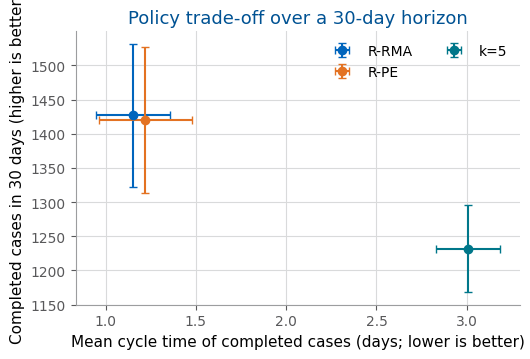

In [6]:
fig, ax = plt.subplots(figsize=(5.4, 3.7))
colors = [TUM_BLUE, TUM_ORANGE, TUM_TEAL]
for color, policy in zip(colors, POLICIES):
    row = policy_summary.loc[policy]
    ax.errorbar(
        row["cycle_time_days"], row["completed_cases"],
        xerr=row["cycle_time_days_ci95"], yerr=row["completed_cases_ci95"],
        fmt="o", ms=6, capsize=3, color=color, label=POLICY_LABELS[policy],
    )
ax.set_xlabel("Mean cycle time of completed cases (days; lower is better)", fontsize=11)
ax.set_ylabel(f"Completed cases in {HORIZON_DAYS} days (higher is better)", fontsize=11)
ax.set_title(f"Policy trade-off over a {HORIZON_DAYS}-day horizon", fontsize=13)
ax.tick_params(labelsize=10)
ax.legend(ncol=2, fontsize=10)
fig.tight_layout()
save_figure(fig, "04_30_policy_tradeoff")
plt.show()

### Operational diagnostics

The case-handover rate describes continuity within one customer case. It is not a direct test of Piled Execution. Piled Execution instead tries to keep a resource on the same activity, so `activity_switch_rate` is the relevant mechanism measure. The W_-only measures isolate fitted work sessions from A_/O_ state changes whose durations are assumed. Event-row and busy-time shares show how strongly each view influences a run. Milestone means are accompanied by the share of arrivals that reach each milestone; comparing means alone would condition on a policy-dependent subset of cases.

In [7]:
diagnostic_columns = [
    "time_to_first_offer_days", "first_offer_reach_share",
    "time_to_decision_days", "decision_reach_share",
    "case_handover_rate", "activity_switch_rate", "rolling_workload_std",
    "w_activity_switch_rate", "w_rolling_workload_std",
    "w_event_share", "ao_event_share", "w_busy_share", "ao_busy_share",
    "median_sessions_per_work_item", "max_sessions_per_work_item",
    "max_session_guard_reached", "max_session_guard_forced_completions",
    "withdrawals", "rare_shortened_work_items",
    "rare_personal_loan_work_items",
]
policy_summary[diagnostic_columns].rename(index=POLICY_LABELS).round(3)

,time_to_first_offer_days,first_offer_reach_share,time_to_decision_days,decision_reach_share,case_handover_rate,activity_switch_rate,rolling_workload_std,w_activity_switch_rate,w_rolling_workload_std,w_event_share,ao_event_share,w_busy_share,ao_busy_share,median_sessions_per_work_item,max_sessions_per_work_item,max_session_guard_reached,max_session_guard_forced_completions,withdrawals,rare_shortened_work_items,rare_personal_loan_work_items
policy,,,,,,,,,,,,,,,,,,,,
R-RMA,0.149,0.973,0.568,0.510,0.815,0.739,0.101,0.131,0.023,0.188,0.812,0.119,0.881,1.000,10.250,0.000,0.000,53.250,0.000,0.000
R-PE,0.149,0.972,0.638,0.508,0.819,0.653,0.100,0.125,0.023,0.188,0.812,0.121,0.879,1.000,10.250,0.000,0.000,52.500,0.000,0.000
k=5,0.919,0.938,2.204,0.457,0.874,0.678,0.091,0.087,0.022,0.175,0.825,0.112,0.888,1.000,10.250,0.000,0.000,364.500,0.000,0.000


## 3. Reproducibility checks and interpretation guardrails

- The runner requires `lifecycle_mode` as a keyword, so future notebooks cannot silently fall back to legacy elapsed durations.
- Every run records and checks its effective capacity, realized roster seed, and arrival model. Policies with the same replication seed use the same roster draw.
- Cache keys also fingerprint the Petri net, repaired decision-point probabilities, visit-conditioned branching, arrivals, permissions, policies, and fitted inputs.
- Active `start` and `resume` events must have an assigned resource, and the resource component must report no unpermitted activity. The number of work items still queued at the finite horizon is retained as a diagnostic rather than treated as completed work.
- Active mode uses unit resource capacity. Consequently, no human resource may have occupation above one.
- Session churn, withdrawals, and the two sparsely observed W_ routes are recorded for every run. Any activation of the 60-session completion guard fails the notebook instead of silently entering the results.
- CRN pairs stochastic inputs by seed, making within-seed policy differences more informative than independent runs.
- Occupation is active busy time overlapping realized calendar availability, divided by that availability. Work continuing past shift end is retained separately as overtime rather than divided by scheduled hours. Staff with zero availability in the horizon are reported and excluded from the denominator; staff who are available but idle count as zero occupation.
- All-activity occupation includes assumed A_/O_ service durations. W_-only occupation uses the same availability denominator but only fitted work sessions. The 60-day report notebook performs the paired zero-duration lower-bound sensitivity.
- Cycle time conditions on natural completion. Completion counts, completion shares, and milestone reach shares must therefore accompany it.

In [8]:
all_run_metrics = policy_run_metrics.copy()

assert (
    policy_run_metrics["resources_evaluated"]
    + policy_run_metrics["zero_availability_resources"]
).eq(len(human_resources)).all()
assert policy_run_metrics["completed_cases"].gt(0).all()
assert all_run_metrics["effective_capacity"].eq(RUN_CONFIG["capacity"]).all()
assert all_run_metrics["effective_roster_seed"].eq(
    all_run_metrics["seed"].map(expected_roster_seed)
).all()
assert all_run_metrics["arrival_model"].eq(RUN_CONFIG["arrival_model"]).all()
assert all_run_metrics["atomic_duration_scale"].eq(RUN_CONFIG["atomic_duration_scale"]).all()
assert all_run_metrics["unpermitted_activities"].eq(0).all()
assert all_run_metrics["missing_resource_starts"].eq(0).all()
assert all_run_metrics["still_queued_at_end"].ge(0).all()
assert all_run_metrics["max_session_guard_reached"].eq(0).all()
assert all_run_metrics["max_session_guard_forced_completions"].eq(0).all()
if RUN_CONFIG["capacity"] == 1:
    assert all_run_metrics["max_resource_occupation"].le(1.0 + 1e-9).all()
assert all_run_metrics.groupby("seed")["effective_roster_seed"].nunique().eq(1).all()

print("All provenance and result sanity checks passed.")
print("Results written to", RESULT_DIR)
print("Figures written to", ROOT / "visualization")

All provenance and result sanity checks passed.
Results written to /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/output/evaluation_30
Figures written to /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/visualization
